# **Spring 2025-2026 CS 412 Recitation 5**
## **Features, Model Complexity & Regularization**

In this recitation, we'll build a model that **predicts a student's final exam score**, step by step, from raw messy data to a clean, regularized pipeline.

The topics we will cover:
1. Feature Types and Encoding
2. Feature normalization
3. Feature engineering
4. Overfitting & model complexity
5. Regularization (Ridge vs Lasso)

## **Section 0 — The Dataset**

We have data on **300 Sabancı students**. For each student we know:

| Feature | Type | Description |
|---|---|---|
| `study_hours` | Real-valued | Average daily study hours |
| `sleep_hours` | Real-valued | Average daily sleep hours |
| `scholarship` | Binary | 1 if on scholarship, 0 otherwise |
| `department` | Categorical | One of: CS, IE, ME, EE |
| `year` | Ordinal | Academic year: 1st, 2nd, 3rd, 4th |
| `dorm_room_size` | Real-valued | Size of dorm room in cm² |
| **`final_score`** | Real-valued | **Target**, final exam score (0–100) |


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

SEED = 412
np.random.seed(SEED)

In [30]:
N = 300

# Real-valued features
study_hours = np.random.uniform(1, 10, N)   # 1 to 10 hours/day
sleep_hours = np.random.uniform(4, 10, N)   # 4 to 10 hours/day

# Binary feature (already numeric, no encoding needed)
scholarship = np.random.randint(0, 2, N)    # 0 or 1

# Categorical feature (no natural order)
departments = np.random.choice(['CS', 'IE', 'ME', 'EE'], N)

# Ordinal feature (has a natural order)
years = np.random.choice(['1st', '2nd', '3rd', '4th'], N)

# Irrelevant feature (completely unrelated to grades)
dorm_room_size = np.random.uniform(1000, 2500, N)  # cm² (intentionally large scale)

# Target: final_score
year_map = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}
dept_map = {'CS': 3, 'IE': 2, 'ME': 1, 'EE': 2}

year_numeric = np.array([year_map[y] for y in years])
dept_numeric = np.array([dept_map[d] for d in departments])
noise        = np.random.normal(0, 5, N)

final_score = (
    5.0 * study_hours      # studying helps a lot
  + 2.0 * sleep_hours      # sleep matters too
  + 8.0 * scholarship      # scholarship students could be more motivated study
  + 1.5 * year_numeric     # older students might do slightly better since they might know more
  + 1.0 * dept_numeric     # small department effect
  + 0.0 * dorm_room_size   # dorm room size: zero effect (remember this!)
  + noise
)

final_score = np.clip(final_score, 0, 100)

In [31]:
df = pd.DataFrame({
    'study_hours'   : study_hours,
    'sleep_hours'   : sleep_hours,
    'scholarship'   : scholarship,
    'department'    : departments,
    'year'          : years,
    'dorm_room_size': dorm_room_size,
    'final_score'   : final_score
})

df.head(10)

,study_hours,sleep_hours,scholarship,department,year,dorm_room_size,final_score
0,9.504705,4.683863,0,EE,3rd,1388.691235,63.994366
1,8.931187,8.657782,1,ME,2nd,2202.032429,68.940928
2,1.296144,4.557451,1,EE,1st,1572.646769,20.586631
3,6.257147,4.283167,0,CS,4th,1702.175617,45.881342
4,2.578118,9.540350,0,IE,1st,2283.044961,37.296091
5,5.376835,8.616926,1,CS,1st,1648.917923,57.809872
6,7.218132,4.382783,0,IE,4th,1962.713153,49.286002
7,2.944484,4.410720,1,ME,2nd,2321.247800,38.591143
8,6.383661,8.492149,1,CS,4th,2050.226647,67.430568
9,5.436279,8.290016,1,EE,2nd,2288.513842,55.011541


In [32]:
df.describe()

,study_hours,sleep_hours,scholarship,dorm_room_size,final_score
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,5.671741,6.816809,0.506667,1773.170952,52.148567
std,2.685755,1.797195,0.500791,434.616311,15.167021
min,1.018313,4.008819,0.000000,1008.452640,17.488393
25%,3.462336,5.115160,0.000000,1407.687081,41.560704
50%,5.488573,6.751872,1.000000,1805.931694,51.128952
75%,8.134572,8.365818,1.000000,2161.478308,63.984494
max,9.982292,9.994534,1.000000,2472.242019,86.915471


### Our features are in different scales:
- `study_hours` and `sleep_hours` are on similar scales (~1–10)
- `dorm_room_size` is on a different scale (~10–25),this will matter soon
- `department` and `year` are **strings**, a model can't use these as-is
- `scholarship` is already 0/1, no encoding needed

**Try it:** What happens if we try to fit a model right now?

In [33]:
# If you try feeding the raw DataFrame into a model you'll get an error, because these raw feature format is not suitable for the model to process
# from sklearn.linear_model import LinearRegression
#
# X_raw = df.drop('final_score', axis=1)
# y     = df['final_score']
#
# model = LinearRegression()
# model.fit(X_raw, y)   # <-- this will throw an error. why?

## **Section 1 - Feature Types and Encoding**

We have 3 types of features:

| Feature | Type | Problem | Solution |
|---|---|---|---|
| `year` | Ordinal | It's a string | Ordinal encoding |
| `department` | Categorical | No natural order | One-hot encoding |
| `scholarship`, `study_hours`, `sleep_hours`, `dorm_room_size` | Binary / Real-valued | Already numeric | Nothing to do |

### 1.1 Ordinal Encoding for `year`

`year` has a natural order: 1st < 2nd < 3rd < 4th. So we can safely map it to numbers that preserve this order.

In [34]:
year_mapping = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}

df['year_encoded'] = df['year'].map(year_mapping)

# Compare before and after,
# This is just for visulization purposes, so that you can see the unique values in the maped version of the 'year' column:
df[['year', 'year_encoded']].drop_duplicates().sort_values('year_encoded')

,year,year_encoded
2,1st,1
1,2nd,2
0,3rd,3
3,4th,4


**Why not use this same approach for `department`?**

If we map CS=1, IE=2, ME=3, EE=4, we are telling the model that CS < IE < ME < EE, which is completely meaningless. The model would think IE is somehow "between" CS and ME. Since there is no real order, we should not invent one.

This is where one-hot encoding comes in.

### 1.2 One-Hot Encoding for `department`

We create one binary column per category. Each column answers a yes/no question: "Is this student in CS?", "Is this student in IE?", etc.

But actually we only need **k-1 = 3 columns** for k=4 categories. If a student is not CS, not IE, and not ME, they must be EE. The last column is redundant and can confuse some models, so we drop it with `drop_first=True`.

In [35]:
dept_dummies = pd.get_dummies(df['department'], prefix='dept', drop_first=True)

dept_dummies.head(8)

,dept_EE,dept_IE,dept_ME
0,True,False,False
1,False,False,True
2,True,False,False
3,False,False,False
4,False,True,False
5,False,False,False
6,False,True,False
7,False,False,True


In [36]:
# Now attach everything together into a clean numeric dataframe
df_encoded = df.drop(columns=['department', 'year', 'year_encoded', 'final_score'])
df_encoded = pd.concat([df_encoded, dept_dummies], axis=1)
df_encoded['year'] = df['year_encoded']

# Our target
y = df['final_score']

print('Shape:', df_encoded.shape)
df_encoded.head()

Shape: (300, 8)


,study_hours,sleep_hours,scholarship,dorm_room_size,dept_EE,dept_IE,dept_ME,year
0,9.504705,4.683863,0,1388.691235,True,False,False,3
1,8.931187,8.657782,1,2202.032429,False,False,True,2
2,1.296144,4.557451,1,1572.646769,True,False,False,1
3,6.257147,4.283167,0,1702.175617,False,False,False,4
4,2.578118,9.540350,0,2283.044961,False,True,False,1


Every column is now numeric. We can now finally feed this into a model.

## **Section 2 - Feature Engineering**

Sometimes the raw features you have are not the best representation of the underlying pattern. You can create new features by combining existing ones.

In our dataset, consider `study_hours` and `sleep_hours`. A student who studies 9 hours but sleeps only 4 is in a very different situation than a student who studies 9 hours and sleeps 9. Neither feature alone captures this, but their ratio does.

We can define a new feature:

**stress_index = study_hours / sleep_hours**

A high value means studying a lot relative to sleep, which could go either way for the final score.

In [37]:
df_encoded['stress_index'] = df_encoded['study_hours'] / df_encoded['sleep_hours']

print('stress_index added. New shape:', df_encoded.shape)
df_encoded[['study_hours', 'sleep_hours', 'stress_index']].head(8)

stress_index added. New shape: (300, 9)


,study_hours,sleep_hours,stress_index
0,9.504705,4.683863,2.029245
1,8.931187,8.657782,1.031579
2,1.296144,4.557451,0.284401
3,6.257147,4.283167,1.460869
4,2.578118,9.540350,0.270233
5,5.376835,8.616926,0.623985
6,7.218132,4.382783,1.646929
7,2.944484,4.410720,0.667575


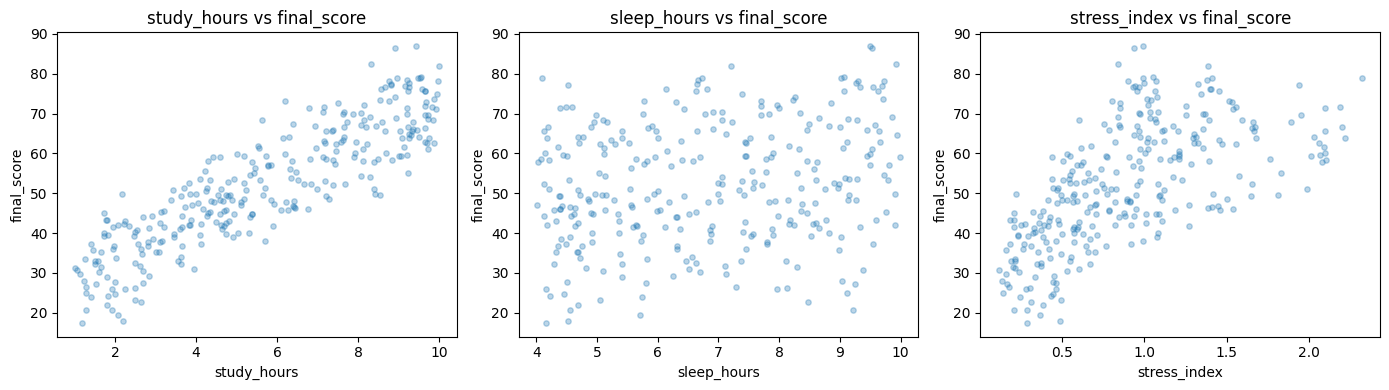

In [38]:
# Does stress_index actually correlate with the final score?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feature in zip(axes, ['study_hours', 'sleep_hours', 'stress_index']):
    ax.scatter(df_encoded[feature], y, alpha=0.3, s=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('final_score')
    ax.set_title(f'{feature} vs final_score')

plt.tight_layout()
plt.show()

**Discussion:** Does `stress_index` show a clearer pattern than `study_hours` or `sleep_hours` alone?

Now we have a richer feature set. But we still have one suspicious feature sitting in our dataset: `dorm_room_size`. Should we drop it manually?

Not necessarily. Manually inspecting correlations is a naive approach. A feature with low individual correlation might still be useful in combination with other features. More importantly, we don't want to make this decision by hand.

In Section 5 we will apply Lasso regularization, and let the model itself decide which features deserve a non-zero coefficient. If `dorm_room_size` is truly useless, its coefficient will go to exactly zero on its own.

In [39]:
# Final feature matrix going into the model
print('Features going into the model:')
for col in df_encoded.columns:
    print(f'  {col}')

Features going into the model:
  study_hours
  sleep_hours
  scholarship
  dorm_room_size
  dept_EE
  dept_IE
  dept_ME
  year
  stress_index


In [40]:
df_encoded

,study_hours,sleep_hours,scholarship,dorm_room_size,dept_EE,dept_IE,dept_ME,year,stress_index
0,9.504705,4.683863,0,1388.691235,True,False,False,3,2.029245
1,8.931187,8.657782,1,2202.032429,False,False,True,2,1.031579
2,1.296144,4.557451,1,1572.646769,True,False,False,1,0.284401
3,6.257147,4.283167,0,1702.175617,False,False,False,4,1.460869
4,2.578118,9.540350,0,2283.044961,False,True,False,1,0.270233
...,...,...,...,...,...,...,...,...,...
295,8.081910,8.337899,1,2435.344844,False,False,True,3,0.969298
296,7.155611,4.585824,1,2057.196592,False,False,True,2,1.560376
297,8.450344,8.823195,0,1167.343864,False,False,False,4,0.957742
298,5.191057,5.816970,1,1694.243513,False,False,True,2,0.892399


## **Section 3 - Feature Normalization**

Before we build our actual model, there is a problem we need to fix first. Look at the scale of our features:

In [41]:
print("Feature ranges:")
for col in df_encoded.columns:
    print(f"  {col:20s}  min={df_encoded[col].min():.2f}  max={df_encoded[col].max():.2f}")

Feature ranges:
  study_hours           min=1.02  max=9.98
  sleep_hours           min=4.01  max=9.99
  scholarship           min=0.00  max=1.00
  dorm_room_size        min=1008.45  max=2472.24
  dept_EE               min=0.00  max=1.00
  dept_IE               min=0.00  max=1.00
  dept_ME               min=0.00  max=1.00
  year                  min=1.00  max=4.00
  stress_index          min=0.11  max=2.32


Notice that `dorm_room_size` ranges from 1008 to 2472, while `scholarship` is just 0 or 1. For any algorithm that computes distances between data points, the large-scale features will completely dominate and the small-scale ones will be ignored.

To see this in action, we will use **k-NN** as a quick experiment. Note that k-NN is not the model we are building in this recitation. We are using it here only because it is the most sensitive algorithm to feature scales, which makes the problem easy to see.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    df_encoded, y, test_size=0.2, random_state=SEED
)

# k-NN on raw (unscaled) features
knn_raw = KNeighborsRegressor(n_neighbors=5)
knn_raw.fit(X_train, y_train)
rmse_raw = np.sqrt(mean_squared_error(y_test, knn_raw.predict(X_test)))

print(f"k-NN RMSE without scaling: {rmse_raw:.2f}")

k-NN RMSE without scaling: 15.56


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # note: we use the SAME scaler fitted on train

# k-NN on scaled features
knn_scaled = KNeighborsRegressor(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
rmse_scaled = np.sqrt(mean_squared_error(y_test, knn_scaled.predict(X_test_scaled)))

print(f"k-NN RMSE with scaling:    {rmse_scaled:.2f}")

k-NN RMSE with scaling:    8.79


**Discussion:** The RMSE dropped just by scaling, without changing the model or the data at all. Why?

A small but important detail: we called `fit_transform()` on the training set but only `transform()` on the test set. Why does this matter?

Fitting the scaler on the test set too would mean we are using information from the test set during training. This is called **data leakage** and it gives you an overly optimistic estimate of your model's performance.

From here on we will use `X_train_scaled` and `X_test_scaled` as our feature matrices. k-NN has done its job, we will not use it again.

**Note:** Decision trees and random forests do not need scaling since they split on thresholds rather than distances. But linear regression, k-NN, SVM and neural networks all do.

## **Section 4 - Underfitting, Overfitting and Model Complexity**

When a model is too simple it fails to capture the real pattern in the data. This is called **underfitting**. When a model is too complex it memorizes the noise in the training data and fails to generalize. This is called **overfitting**.

There are two main ways overfitting can happen:
- **Model is too complex** for the data (too many parameters)
- **Data is too small** for the model (not enough examples to generalize)

We will demonstrate both.

### Part A - Model Complexity (Polynomial Degree)

We will temporarily use only `study_hours` to predict `final_score`. This lets us plot the fitted curve in 2D and see exactly what is happening.

To make the overfitting effect clearly visible, we use a small training set of only 45 samples here. This is intentional: we want to see what happens when a complex model has too little data to learn from. We will go back to the full dataset in Part B.

In [44]:
# We'll only use study_hours for this part
X_study = df[['study_hours']].values
y_study = df['final_score'].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_study, y_study, test_size=0.85, random_state=SEED
)

degrees = [1, 3, 6, 9, 12, 15]
train_errors = []
test_errors  = []

for d in degrees:
    poly  = PolynomialFeatures(degree=d)
    model = LinearRegression()

    X_train_poly = poly.fit_transform(X_train_s)
    X_test_poly  = poly.transform(X_test_s)

    model.fit(X_train_poly, y_train_s)

    train_rmse = np.sqrt(mean_squared_error(y_train_s, model.predict(X_train_poly)))
    test_rmse  = np.sqrt(mean_squared_error(y_test_s,  model.predict(X_test_poly)))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

    print(f"Degree {d}:  Train RMSE = {train_rmse:.2f}   Test RMSE = {test_rmse:.2f}")

Degree 1:  Train RMSE = 7.32   Test RMSE = 7.74
Degree 3:  Train RMSE = 7.30   Test RMSE = 7.74
Degree 6:  Train RMSE = 7.09   Test RMSE = 8.17
Degree 9:  Train RMSE = 6.82   Test RMSE = 8.57
Degree 12:  Train RMSE = 6.70   Test RMSE = 9.57
Degree 15:  Train RMSE = 6.73   Test RMSE = 9.15


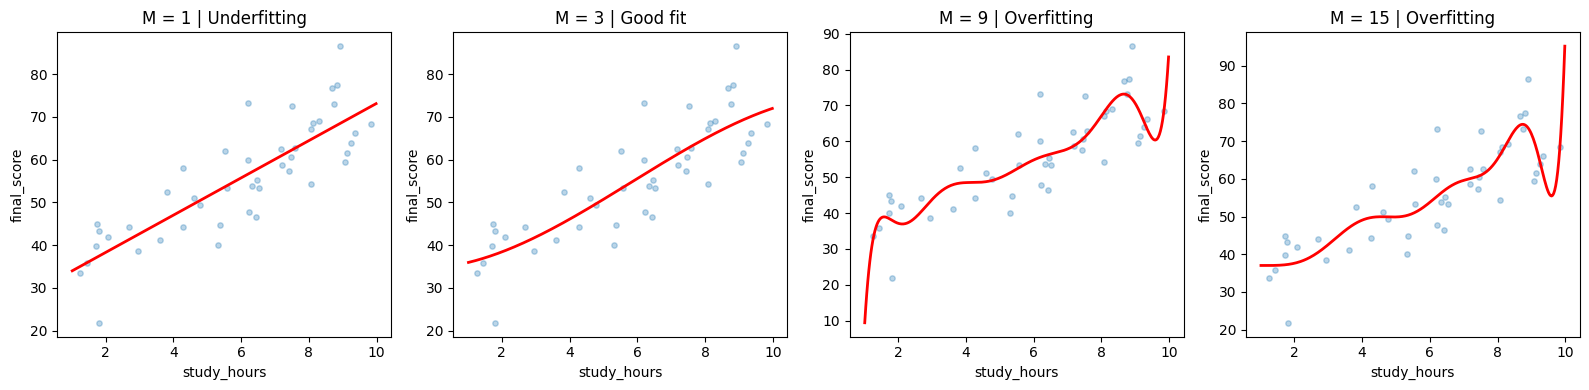

In [45]:
degrees_plot = [1, 3, 9, 15]
labels = {1: 'Underfitting', 3: 'Good fit', 9: 'Overfitting', 15: 'Overfitting'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
x_range = np.linspace(X_study.min(), X_study.max(), 300).reshape(-1, 1)

for ax, d in zip(axes, degrees_plot):
    poly  = PolynomialFeatures(degree=d)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_train_s), y_train_s) # poly.fit_transform is literally creating new columns in the data. Previously you had say [3], with degree 3, you will have [3, 9]

    y_pred = model.predict(poly.transform(x_range))

    ax.scatter(X_train_s, y_train_s, alpha=0.3, s=15)
    ax.plot(x_range, y_pred, color='red', linewidth=2)
    ax.set_xlabel('study_hours')
    ax.set_ylabel('final_score')
    ax.set_title(f'M = {d} | {labels[d]}')

plt.tight_layout()
plt.show()

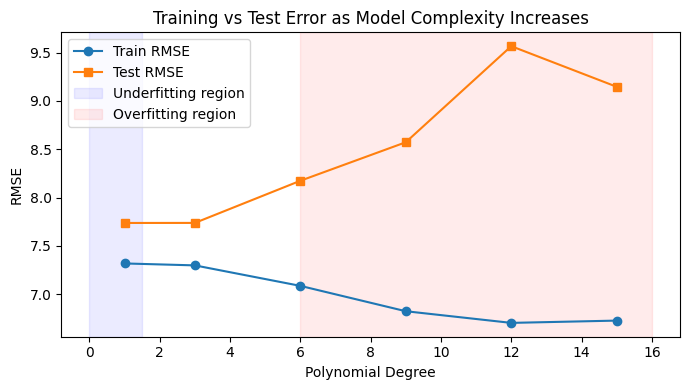

In [46]:
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_errors, marker='o', label='Train RMSE')
plt.plot(degrees, test_errors,  marker='s', label='Test RMSE')

# Shade underfitting and overfitting regions
plt.axvspan(0, 1.5, alpha=0.08, color='blue', label='Underfitting region')
plt.axvspan(6, 16,  alpha=0.08, color='red',  label='Overfitting region')

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Training vs Test Error as Model Complexity Increases')
plt.legend()
plt.tight_layout()
plt.show()

- **Degree 1 (underfitting):** Model is too simple.
- **Degree 3 (sweet spot):** Test RMSE is at its lowest here.
- **Degree 6 onwards (overfitting):** Test RMSE starts climbing while train RMSE keeps going down.

> **Discussion:** Look at the degree 15 curve. Does it look like it learned anything meaningful?

### Part B - Data Size

Now back to our full dataset with all features and plain linear regression. Model complexity is fixed. We vary the training set size and watch what happens.

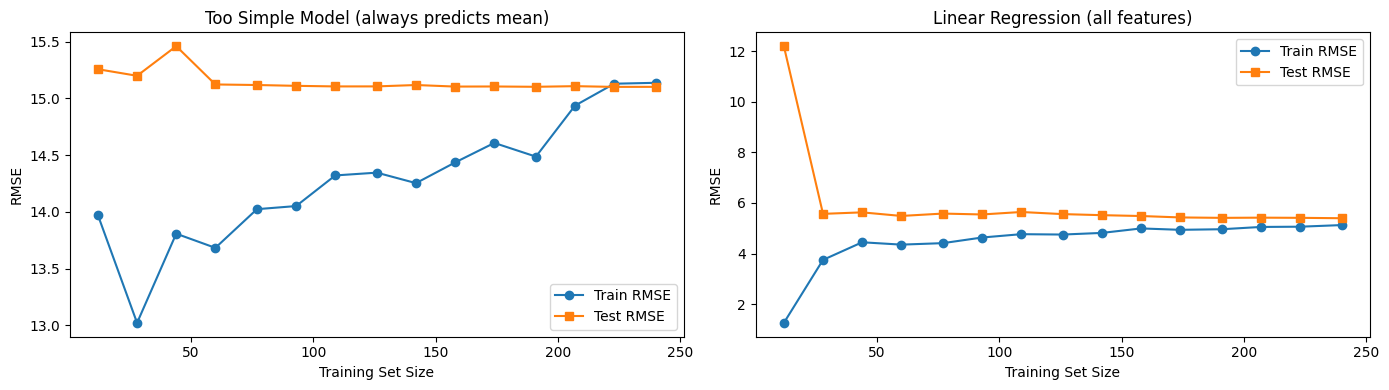

In [47]:
from sklearn.model_selection import learning_curve
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

y_full = y.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (model, title) in zip(axes, [
    (DummyRegressor(strategy='mean'),  'Too Simple Model (always predicts mean)'),
    (Pipeline([
        ('scaler', MinMaxScaler()),
        ('model',  LinearRegression())
    ]),                                'Linear Regression (all features)')
]):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        df_encoded, y_full,
        train_sizes=np.linspace(0.05, 1.0, 15), # creates 15 evenly spced values like: [0.05, 0.12, 0.19, 0.26, ..., 1.0]
        scoring='neg_root_mean_squared_error',
        cv=5,
        random_state=SEED
    )

    train_rmse_lc = -train_scores.mean(axis=1)
    test_rmse_lc  = -test_scores.mean(axis=1)

    ax.plot(train_sizes, train_rmse_lc, marker='o', label='Train RMSE')
    ax.plot(train_sizes, test_rmse_lc,  marker='s', label='Test RMSE')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

**Left plot (too simple model):** The dummy model always predicts the mean score regardless of features. Both train and test errors are high and stay high no matter how much data you add. This is underfitting. More data cannot save a model that is fundamentally too simple.

**Right plot (linear regression):** With very few samples there is a visible gap between train and test RMSE. As we add more data the two curves converge, meaning the model starts generalizing better.

> **Key insight:** Overfitting is about the relationship between model complexity and data size. The same model can overfit with 10 samples and generalize well with 200. And a model that is too simple will underfit no matter how much data you give it.

---

So we have two problems:
1. Model too complex relative to data size: overfitting
2. Model too simple: underfitting, more data will not help

But in practice we cannot always collect more data. Regularization is a way to reduce overfitting without changing the data at all, by penalizing the model for having large coefficients.

## **Section 5 - Regularization**

We saw that with limited data, linear regression overfits. One solution is to get more data, but that is not always possible.

Regularization is a way to constrain the model by penalizing large coefficients. Instead of just minimizing the training error, we minimize:

**Loss = Training Error + lambda * penalty(coefficients)**

- **Ridge (L2):** penalty is the sum of squared coefficients
- **Lasso (L1):** penalty is the sum of absolute values of coefficients

`lambda` controls how much we penalize. Higher lambda means more regularization, simpler model. Lower lambda means less regularization, closer to plain linear regression.

We will use our full dataset with all features.

In [52]:
from sklearn.linear_model import Ridge, Lasso

# Baseline: plain linear regression, no regularization
baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test_scaled)))

print(f"Baseline Linear Regression Test RMSE: {baseline_rmse:.2f}")
print()
print("Coefficients:")
for name, coef in zip(df_encoded.columns, baseline.coef_):
    print(f"  {name:20s}  {coef:.4f}")

Baseline Linear Regression Test RMSE: 5.45

Coefficients:
  study_hours           46.7575
  sleep_hours           9.3121
  scholarship           7.8452
  dorm_room_size        0.4088
  dept_EE               -1.4961
  dept_IE               -0.6924
  dept_ME               -0.9211
  year                  4.1014
  stress_index          -1.3885


### Regularization Path

Now let's see what happens to each feature's coefficient as we increase lambda. We will plot this for both Ridge and Lasso side by side.

A **regularization path** shows how coefficients change as lambda increases from very small (almost no regularization) to very large (very strong regularization).

In [54]:
lambdas = np.logspace(-3, 3, 100)  # from 0.001 to 1000, 100 evenly spaced values on a log scale.
feature_names = df_encoded.columns.tolist()

ridge_coefs = []
lasso_coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=lam, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

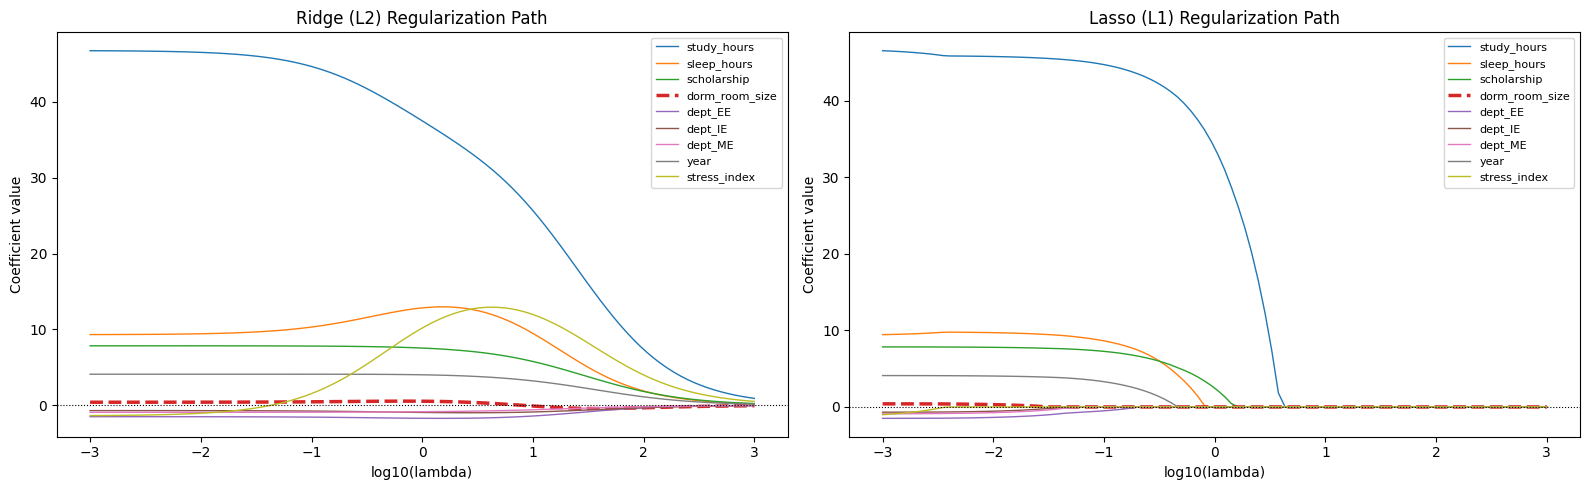

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, coefs, title in zip(axes,
                             [ridge_coefs, lasso_coefs],
                             ['Ridge (L2) Regularization Path',
                              'Lasso (L1) Regularization Path']):
    for i, name in enumerate(feature_names):
        # Make dorm_room_size stand out
        lw        = 2.5 if name == 'dorm_room_size' else 1
        linestyle = '--' if name == 'dorm_room_size' else '-'
        ax.plot(np.log10(lambdas), coefs[:, i],
                label=name, linewidth=lw, linestyle=linestyle)

    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_xlabel('log10(lambda)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [56]:
# Pick a large lambda to inspect coefficients
# lam_inspect = 100  # log10(100) = 2, which is in the "shrinking" region
lam_inspect = 1  # log10(10) = 0, which is in the "shrinking" region

ridge_inspect = Ridge(alpha=lam_inspect)
ridge_inspect.fit(X_train_scaled, y_train)

lasso_inspect = Lasso(alpha=lam_inspect, max_iter=10000)
lasso_inspect.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Baseline'  : baseline.coef_,
    'Ridge'     : ridge_inspect.coef_,
    'Lasso'     : lasso_inspect.coef_
}).set_index('Feature').round(6)

print(f"Coefficient comparison at lambda = {lam_inspect}:")
print(coef_df.to_string())

Coefficient comparison at lambda = 1:
                 Baseline      Ridge     Lasso
Feature                                       
study_hours     46.757492  37.495022  33.80917
sleep_hours      9.312091  12.841328   0.00000
scholarship      7.845156   7.548165   2.45731
dorm_room_size   0.408836   0.540866  -0.00000
dept_EE         -1.496080  -1.706384  -0.00000
dept_IE         -0.692393  -0.937491  -0.00000
dept_ME         -0.921051  -0.839332   0.00000
year             4.101426   4.024694   0.00000
stress_index    -1.388459  10.183787   0.00000


### What just happened?

- **No regularization:** all coefficients are non-zero, including `dorm_room_size`
- **Ridge:** all coefficients shrank toward zero, but none of them are exactly zero. Ridge cannot do feature selection.
- **Lasso:** `dorm_room_size` coefficient is exactly zero. Lasso figured out on its own that this feature is useless, without us ever telling it.

Remember earlier when we said "we will let the model decide which features to drop"? This is exactly what just happened.

> **Key takeaway:** Lasso does not just regularize, it does automatic **feature selection**. Ridge shrinks everything but keeps all features. Which one you use depends on whether you believe most features are relevant (Ridge) or that only a few features truly matter (Lasso).